In [2]:
import pandas as pd

# Cargar el dataset
ruta_csv = 'spaphish/Spaphish dataset - DiB.csv'
df = pd.read_csv(ruta_csv, sep=';', encoding='utf-8')

print(f"✅ Dataset cargado: {len(df)} emails")
print(f"Columnas: {df.columns.tolist()[:5]}...")

✅ Dataset cargado: 1395 emails
Columnas: ['hash', 'subject', 'body', 'date', 'url_count']...


In [6]:
from sklearn.model_selection import train_test_split

X = df['text']
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Entrenamiento: {len(X_train)} emails")
print(f"Prueba: {len(X_test)} emails")
print(f"Balance en train: {y_train.value_counts(normalize=True)[1]*100:.1f}% phishing")

Entrenamiento: 1116 emails
Prueba: 279 emails
Balance en train: 52.4% phishing


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import os

# Vectorizar
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Entrenar
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_vec, y_train)

# Evaluar
y_pred = rf.predict(X_test_vec)
print("\n=== RANDOM FOREST CON SPAPHISH ===")
print(classification_report(y_test, y_pred, target_names=['Seguro', 'Phishing']))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
print(f"\nMatriz de Confusión:")
print(f"               Seguro  Phishing")
print(f"Real Seguro     {cm[0,0]}       {cm[0,1]}")
print(f"     Phishing    {cm[1,0]}        {cm[1,1]}")

# Guardar modelo
os.makedirs('output', exist_ok=True)
joblib.dump(rf, 'output/rf_model_spaphish.pkl')
joblib.dump(vectorizer, 'output/vectorizer_spaphish.pkl')
print("\n✅ Modelo Random Forest guardado en output/")


=== RANDOM FOREST CON SPAPHISH ===
              precision    recall  f1-score   support

      Seguro       0.92      0.98      0.95       133
    Phishing       0.98      0.92      0.95       146

    accuracy                           0.95       279
   macro avg       0.95      0.95      0.95       279
weighted avg       0.95      0.95      0.95       279


Matriz de Confusión:
               Seguro  Phishing
Real Seguro     130       3
     Phishing    11        135

✅ Modelo Random Forest guardado en output/


In [8]:
import pandas as pd
import torch
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import numpy as np
import os

# Usar el mismo df que ya tienes cargado
X = df['text']
y = df['Label']

# Dividir (misma división que Random Forest)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Entrenamiento: {len(X_train)} emails")
print(f"Prueba: {len(X_test)} emails")

# Tokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

class PhishingDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts.iloc[idx]),
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels.iloc[idx], dtype=torch.long)
        }

train_dataset = PhishingDataset(X_train, y_train, tokenizer)
test_dataset = PhishingDataset(X_test, y_test, tokenizer)

# Modelo
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return {
        'accuracy': accuracy_score(labels, predictions),
        'f1': f1_score(labels, predictions)
    }

training_args = TrainingArguments(
    output_dir='./distilbert_spaphish_results',
    num_train_epochs=4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    report_to='none'
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

# Entrenar
print("🚀 Entrenando DistilBERT con SpaPhish...")
trainer.train()

# Evaluar
results = trainer.evaluate()
print(f"\n=== DISTILBERT CON SPAPHISH ===")
print(f"Accuracy: {results['eval_accuracy']:.4f}")
print(f"F1-Score: {results['eval_f1']:.4f}")

# Matriz de confusión
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids

cm = confusion_matrix(labels, preds)
print(f"\nMatriz de Confusión:")
print(f"               Seguro  Phishing")
print(f"Real Seguro     {cm[0,0]}       {cm[0,1]}")
print(f"     Phishing    {cm[1,0]}        {cm[1,1]}")

# Guardar modelo
os.makedirs('output', exist_ok=True)
model.save_pretrained('output/distilbert_spaphish')
tokenizer.save_pretrained('output/distilbert_spaphish')
print("\n✅ Modelo DistilBERT guardado en output/distilbert_spaphish")

Entrenamiento: 1116 emails
Prueba: 279 emails


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


🚀 Entrenando DistilBERT con SpaPhish...


C:\Users\Capstone-Project-Phishing-AI\phishing-env\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\Capstone-Project-Phishing-AI\phishing-env\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].
C:\Users\Capstone-Project-Phishing-AI\phishing-env\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


RuntimeError: on_train_begin must be called before on_evaluate

In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Obtener predicciones del modelo entrenado
print("Generando predicciones...")
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids

# Reporte de clasificación
print("\n=== DISTILBERT CON SPAPHISH (Evaluación manual) ===")
print(classification_report(labels, preds, target_names=['Seguro', 'Phishing']))

# Matriz de confusión
cm = confusion_matrix(labels, preds)
print(f"\nMatriz de Confusión:")
print(f"               Seguro  Phishing")
print(f"Real Seguro     {cm[0,0]}       {cm[0,1]}")
print(f"     Phishing    {cm[1,0]}        {cm[1,1]}")

# Guardar modelo (ya está guardado, pero confirmamos)
print("\n✅ Modelo guardado en output/distilbert_spaphish")

Generando predicciones...


C:\Users\Capstone-Project-Phishing-AI\phishing-env\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



=== DISTILBERT CON SPAPHISH (Evaluación manual) ===
              precision    recall  f1-score   support

      Seguro       0.95      0.92      0.94       133
    Phishing       0.93      0.95      0.94       146

    accuracy                           0.94       279
   macro avg       0.94      0.94      0.94       279
weighted avg       0.94      0.94      0.94       279


Matriz de Confusión:
               Seguro  Phishing
Real Seguro     123       10
     Phishing    7        139

✅ Modelo guardado en output/distilbert_spaphish


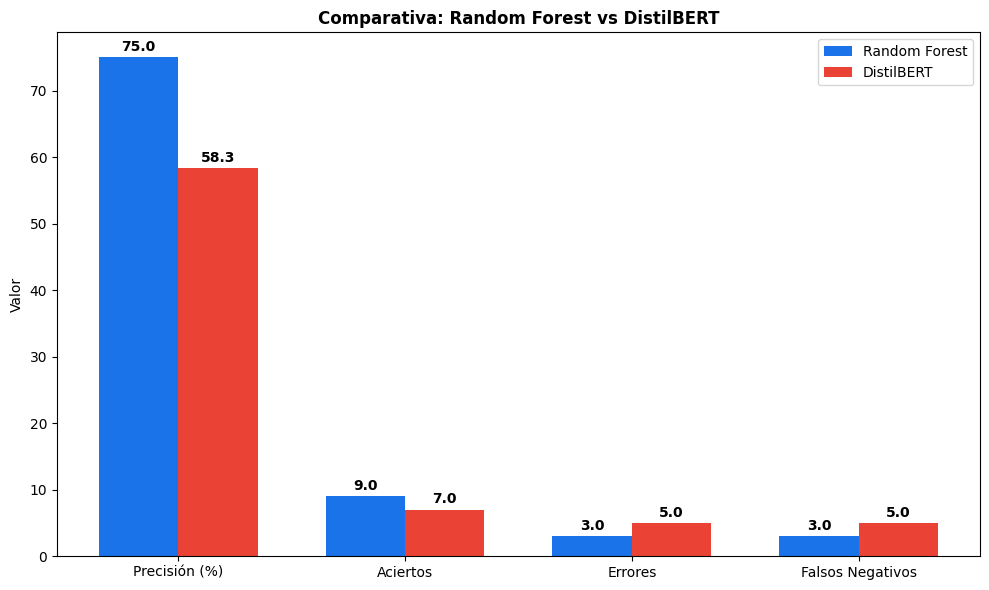

✅ Gráfica guardada en 'output/comparativa_rf_vs_db_compact.png'


In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Datos
metricas = ['Precisión (%)', 'Aciertos', 'Errores', 'Falsos Negativos']
rf_valores = [75.0, 9, 3, 3]
db_valores = [58.3, 7, 5, 5]

x = np.arange(len(metricas))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, rf_valores, width, label='Random Forest', color='#1a73e8')
bars2 = ax.bar(x + width/2, db_valores, width, label='DistilBERT', color='#ea4335')

ax.set_ylabel('Valor')
ax.set_title('Comparativa: Random Forest vs DistilBERT', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.legend()

# Añadir valores en las barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('output/comparativa_rf_vs_db_compact.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Gráfica guardada en 'output/comparativa_rf_vs_db_compact.png'")

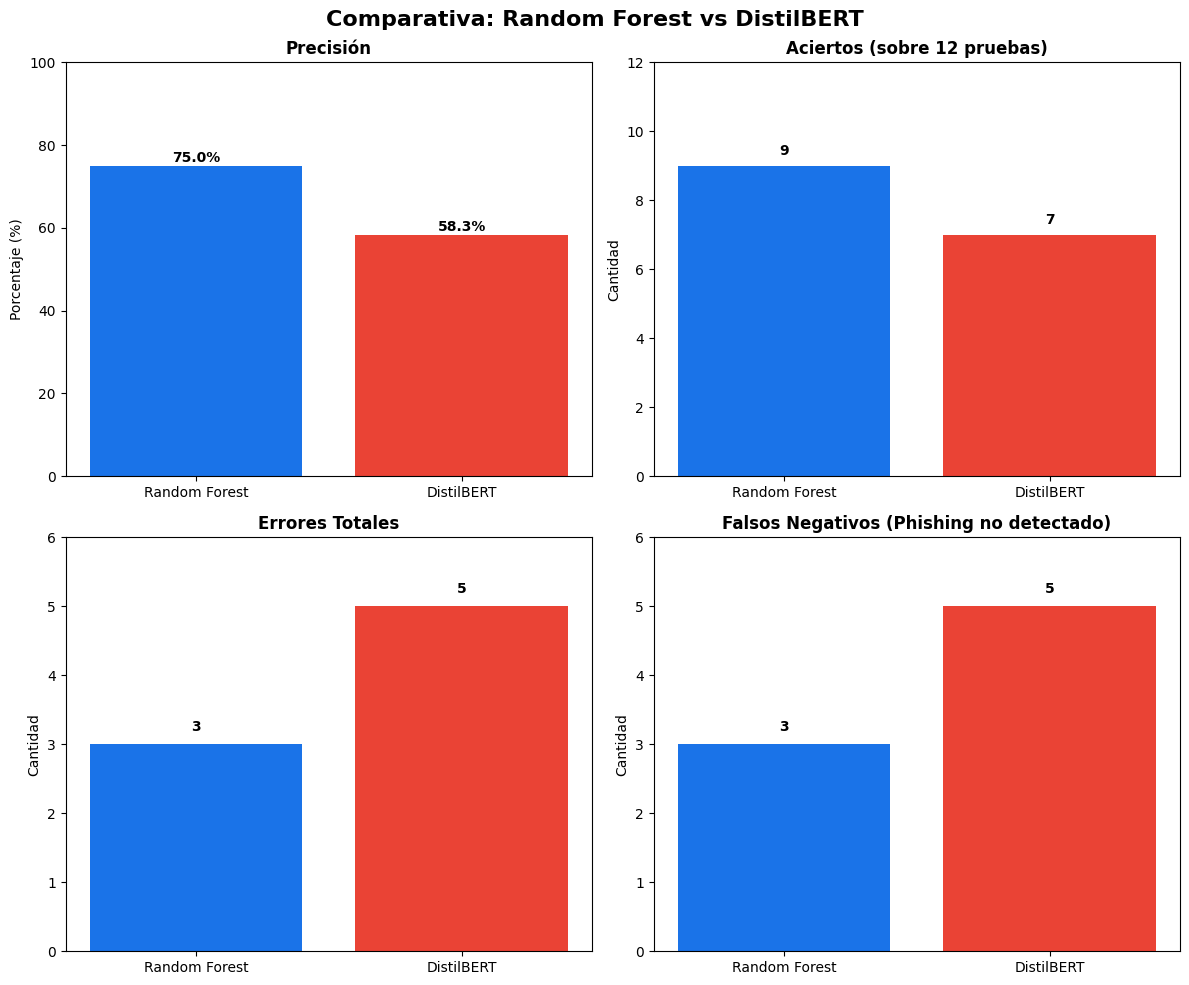

✅ Gráfica guardada en 'output/comparativa_rf_vs_db.png'


In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Datos
modelos = ['Random Forest', 'DistilBERT']
precision = [75.0, 58.3]
aciertos = [9, 7]
errores = [3, 5]
falsos_negativos = [3, 5]

# Colores
colors = ['#1a73e8', '#ea4335']

# Crear figura con 4 subgráficos
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Comparativa: Random Forest vs DistilBERT', fontsize=16, fontweight='bold')

# 1. Gráfico de Precisión
ax1 = axes[0, 0]
bars1 = ax1.bar(modelos, precision, color=colors)
ax1.set_ylabel('Porcentaje (%)')
ax1.set_title('Precisión', fontweight='bold')
ax1.set_ylim(0, 100)
for bar, val in zip(bars1, precision):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val}%', ha='center', fontweight='bold')

# 2. Gráfico de Aciertos
ax2 = axes[0, 1]
bars2 = ax2.bar(modelos, aciertos, color=colors)
ax2.set_ylabel('Cantidad')
ax2.set_title('Aciertos (sobre 12 pruebas)', fontweight='bold')
ax2.set_ylim(0, 12)
for bar, val in zip(bars2, aciertos):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val}', ha='center', fontweight='bold')

# 3. Gráfico de Errores Totales
ax3 = axes[1, 0]
bars3 = ax3.bar(modelos, errores, color=colors)
ax3.set_ylabel('Cantidad')
ax3.set_title('Errores Totales', fontweight='bold')
ax3.set_ylim(0, 6)
for bar, val in zip(bars3, errores):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'{val}', ha='center', fontweight='bold')

# 4. Gráfico de Falsos Negativos
ax4 = axes[1, 1]
bars4 = ax4.bar(modelos, falsos_negativos, color=colors)
ax4.set_ylabel('Cantidad')
ax4.set_title('Falsos Negativos (Phishing no detectado)', fontweight='bold')
ax4.set_ylim(0, 6)
for bar, val in zip(bars4, falsos_negativos):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'{val}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('output/comparativa_rf_vs_db.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Gráfica guardada en 'output/comparativa_rf_vs_db.png'")

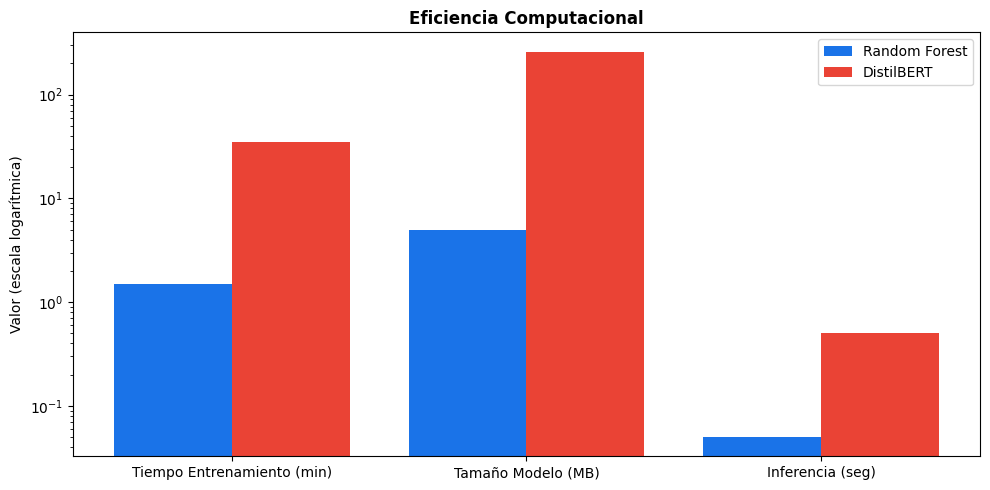

In [17]:
import matplotlib.pyplot as plt

categorias = ['Tiempo Entrenamiento (min)', 'Tamaño Modelo (MB)', 'Inferencia (seg)']
rf_vals = [1.5, 5, 0.05]
db_vals = [35, 260, 0.5]

x = range(len(categorias))
plt.figure(figsize=(10, 5))
plt.bar([i - 0.2 for i in x], rf_vals, width=0.4, label='Random Forest', color='#1a73e8')
plt.bar([i + 0.2 for i in x], db_vals, width=0.4, label='DistilBERT', color='#ea4335')
plt.yscale('log')
plt.ylabel('Valor (escala logarítmica)')
plt.title('Eficiencia Computacional', fontweight='bold')
plt.xticks(x, categorias)
plt.legend()
plt.tight_layout()
plt.savefig('output/eficiencia_computacional.png', dpi=150)
plt.show()

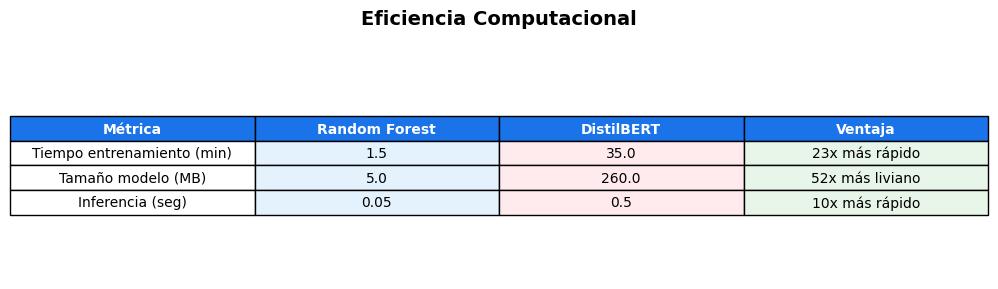

✅ Tabla guardada en 'output/tabla_eficiencia.png'


In [18]:
import matplotlib.pyplot as plt
import pandas as pd

# Datos
data = {
    'Métrica': ['Tiempo entrenamiento (min)', 'Tamaño modelo (MB)', 'Inferencia (seg)'],
    'Random Forest': [1.5, 5, 0.05],
    'DistilBERT': [35, 260, 0.5],
    'Ventaja': ['23x más rápido', '52x más liviano', '10x más rápido']
}

df = pd.DataFrame(data)

# Crear figura con tabla
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')
ax.axis('tight')

table = ax.table(cellText=df.values, colLabels=df.columns, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

# Colorear celdas
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#1a73e8')
        cell.set_text_props(weight='bold', color='white')
    elif col == 3:  # Columna Ventaja
        cell.set_facecolor('#e8f5e9')
    elif col == 1:  # Columna RF
        cell.set_facecolor('#e3f2fd')
    elif col == 2:  # Columna DB
        cell.set_facecolor('#ffebee')

plt.title('Eficiencia Computacional', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('output/tabla_eficiencia.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Tabla guardada en 'output/tabla_eficiencia.png'")

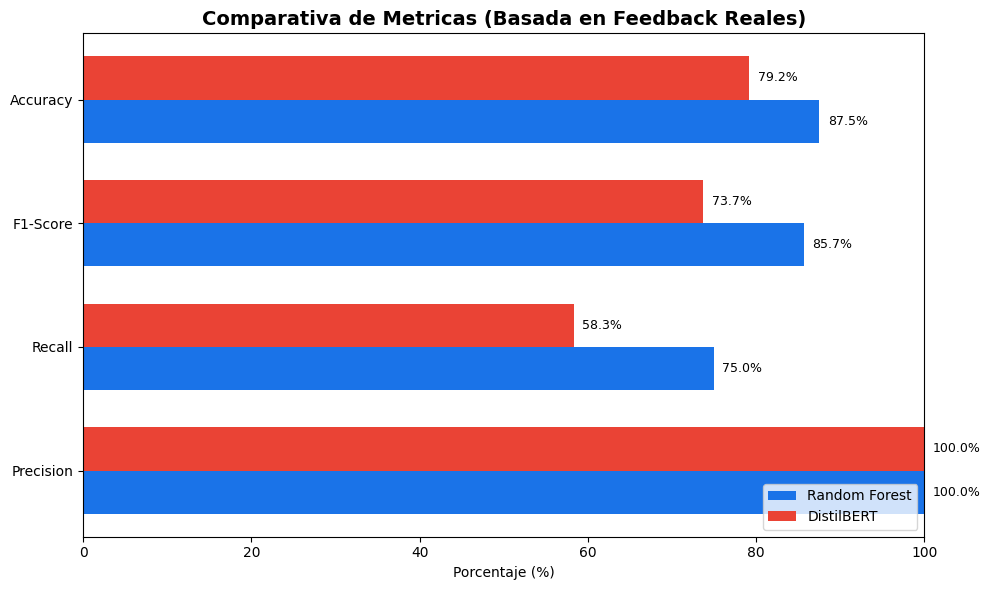

✅ Guardado: fig_barras_horizontales.png


In [3]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))

# Datos CORREGIDOS
metricas = ['Precision', 'Recall', 'F1-Score', 'Accuracy']
rf_vals = [100.0, 75.0, 85.7, 87.5]
db_vals = [100.0, 58.3, 73.7, 79.2]

y_pos = np.arange(len(metricas))
height = 0.35

bars1 = ax.barh(y_pos - height/2, rf_vals, height, label='Random Forest', color='#1a73e8')
bars2 = ax.barh(y_pos + height/2, db_vals, height, label='DistilBERT', color='#ea4335')

ax.set_yticks(y_pos)
ax.set_yticklabels(metricas)
ax.set_xlabel('Porcentaje (%)')
ax.set_title('Comparativa de Metricas (Basada en Feedback Reales)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim(0, 100)

for bar in bars1:
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
            f'{bar.get_width():.1f}%', va='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
            f'{bar.get_width():.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig_barras_horizontales.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Guardado: fig_barras_horizontales.png")

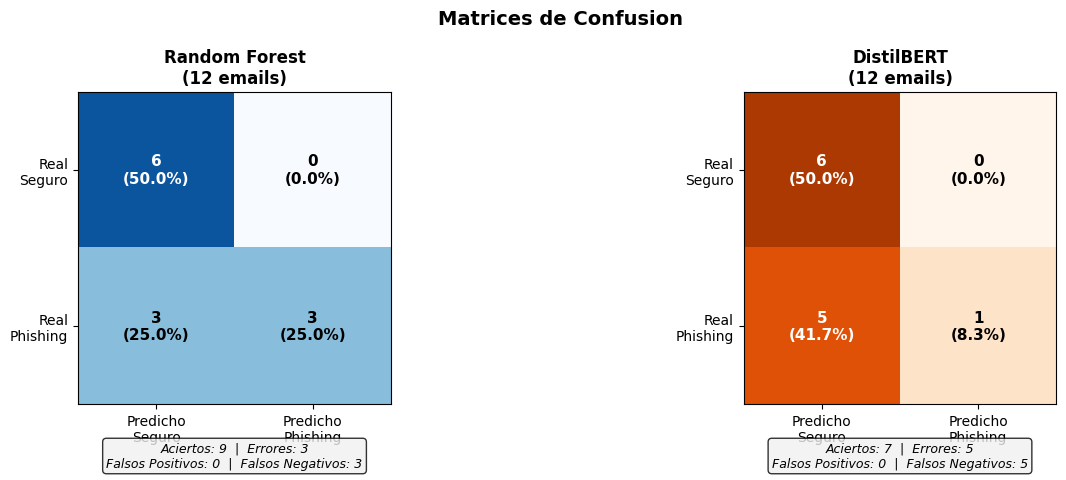

✅ Guardado: output/fig_matrices_mejoradas.png


In [3]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Datos CORREGIDOS (total = 12 emails)
matrices = {
    'Random Forest': {'matriz': np.array([[6, 0], [3, 3]]), 'total': 12, 'color': 'Blues'},
    'DistilBERT': {'matriz': np.array([[6, 0], [5, 1]]), 'total': 12, 'color': 'Oranges'}
}

for ax, (nombre, datos) in zip(axes, matrices.items()):
    cm = datos['matriz']
    total = datos['total']
    cm_pct = (cm / total * 100) if total > 0 else cm
    
    im = ax.imshow(cm, cmap=datos['color'], vmin=0, vmax=7)
    
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Predicho\nSeguro', 'Predicho\nPhishing'])
    ax.set_yticklabels(['Real\nSeguro', 'Real\nPhishing'])
    ax.set_title(f'{nombre}\n({total} emails)', fontweight='bold')
    
    for i in range(2):
        for j in range(2):
            valor = cm[i, j]
            porcentaje = cm_pct[i, j]
            if valor > 0 or (i == 0 and j == 1):
                ax.text(j, i, f'{valor}\n({porcentaje:.1f}%)', 
                       ha='center', va='center', fontsize=11, weight='bold',
                       color='white' if valor > 3 else 'black')
    
    tn, fp, fn, tp = cm.ravel()
    ax.text(0.5, -0.2, 
            f'Aciertos: {tp + tn}  |  Errores: {fp + fn}\n'
            f'Falsos Positivos: {fp}  |  Falsos Negativos: {fn}',
            transform=ax.transAxes, ha='center', fontsize=9, style='italic',
            bbox=dict(boxstyle='round', facecolor='#f0f0f0', alpha=0.8))

plt.suptitle('Matrices de Confusion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_matrices_mejoradas.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Guardado: output/fig_matrices_mejoradas.png")

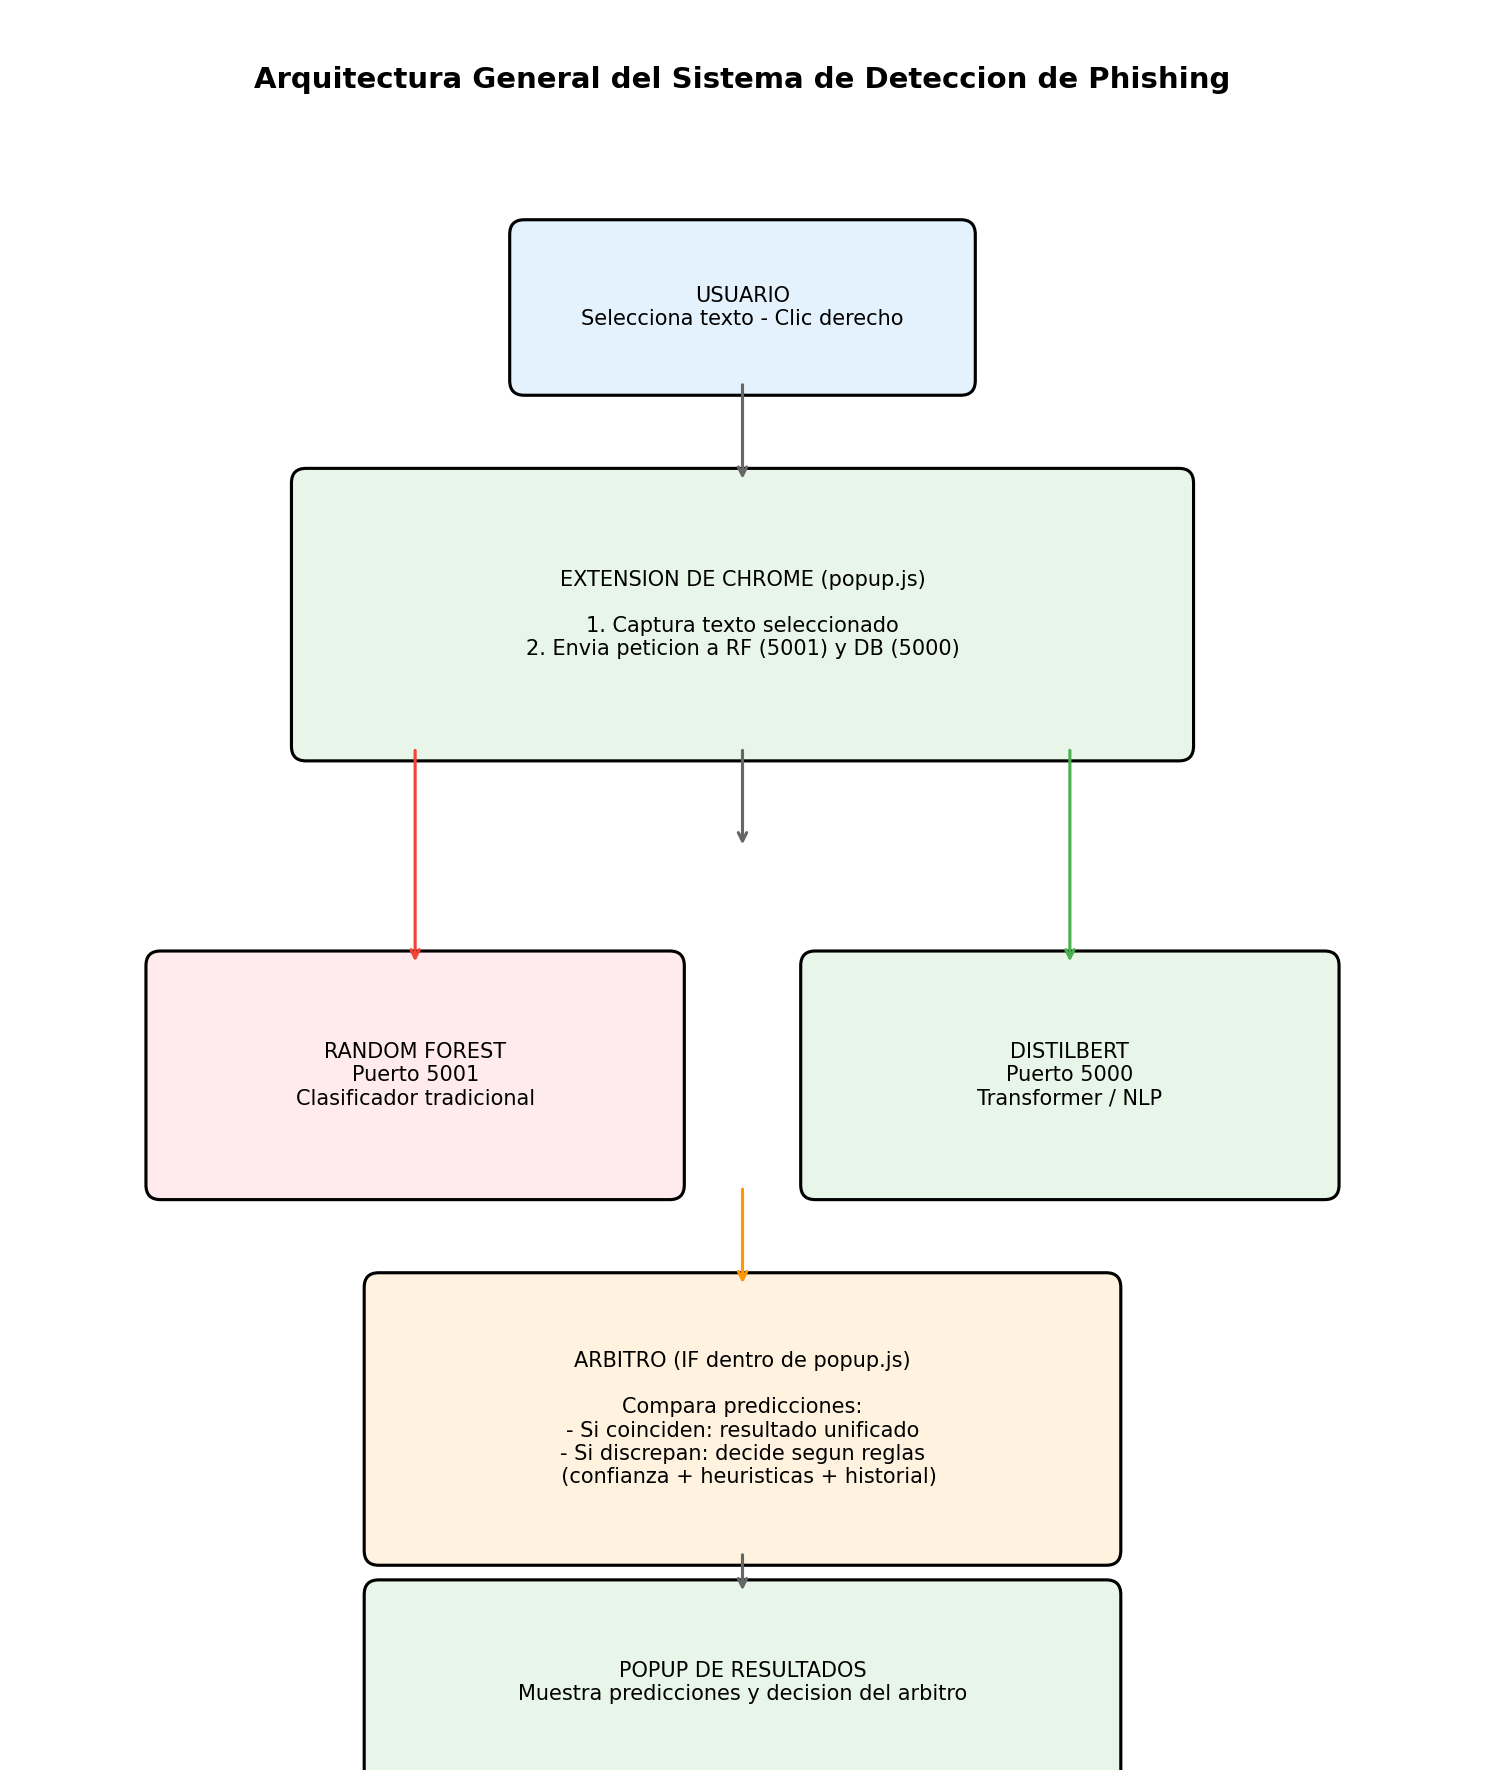

In [8]:
# diagrama_arquitectura.py
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(1, 1, figsize=(10, 12))
ax.set_xlim(0, 10)
ax.set_ylim(0, 12)
ax.axis('off')

def caja(x, y, w, h, texto, color):
    rect = patches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.1",
                                   facecolor=color, edgecolor='black', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, texto, ha='center', va='center', fontsize=10)

def flecha(x1, y1, x2, y2, color='#666'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
               arrowprops=dict(arrowstyle='->', color=color, lw=1.5))

# Título
ax.text(5, 11.5, 'Arquitectura General del Sistema de Deteccion de Phishing', 
        ha='center', fontsize=14, fontweight='bold')

# Usuario
caja(3.5, 9.5, 3, 1, 'USUARIO\nSelecciona texto - Clic derecho', '#e3f2fd')
flecha(5, 9.5, 5, 8.8)

# Extensión Chrome
caja(2, 7.0, 6, 1.8, 'EXTENSION DE CHROME (popup.js)\n\n1. Captura texto seleccionado\n2. Envia peticion a RF (5001) y DB (5000)', '#e8f5e9')
flecha(5, 7.0, 5, 6.3)

# Random Forest
caja(1, 4.0, 3.5, 1.5, 'RANDOM FOREST\nPuerto 5001\nClasificador tradicional', '#ffebee')
flecha(2.75, 7.0, 2.75, 5.5, '#f44336')  # Rojo para RF

# DistilBERT
caja(5.5, 4.0, 3.5, 1.5, 'DISTILBERT\nPuerto 5000\nTransformer / NLP', '#e8f5e9')
flecha(7.25, 7.0, 7.25, 5.5, '#4caf50')  # Verde para DB

# ÁRBITRO (IF dentro de popup.js)
caja(2.5, 1.5, 5, 1.8, 'ARBITRO (IF dentro de popup.js)\n\nCompara predicciones:\n- Si coinciden: resultado unificado\n- Si discrepan: decide segun reglas\n  (confianza + heuristicas + historial)', '#fff3e0')
flecha(5, 4.0, 5, 3.3, '#ff9800')  # Naranja para el ÁRBITRO

# Popup de resultados
caja(2.5, 0, 5, 1.2, 'POPUP DE RESULTADOS\nMuestra predicciones y decision del arbitro', '#e8f5e9')
flecha(5, 1.5, 5, 1.2)

plt.tight_layout()
plt.savefig('fig_arquitectura_sistema.png', dpi=150, bbox_inches='tight')
plt.show()

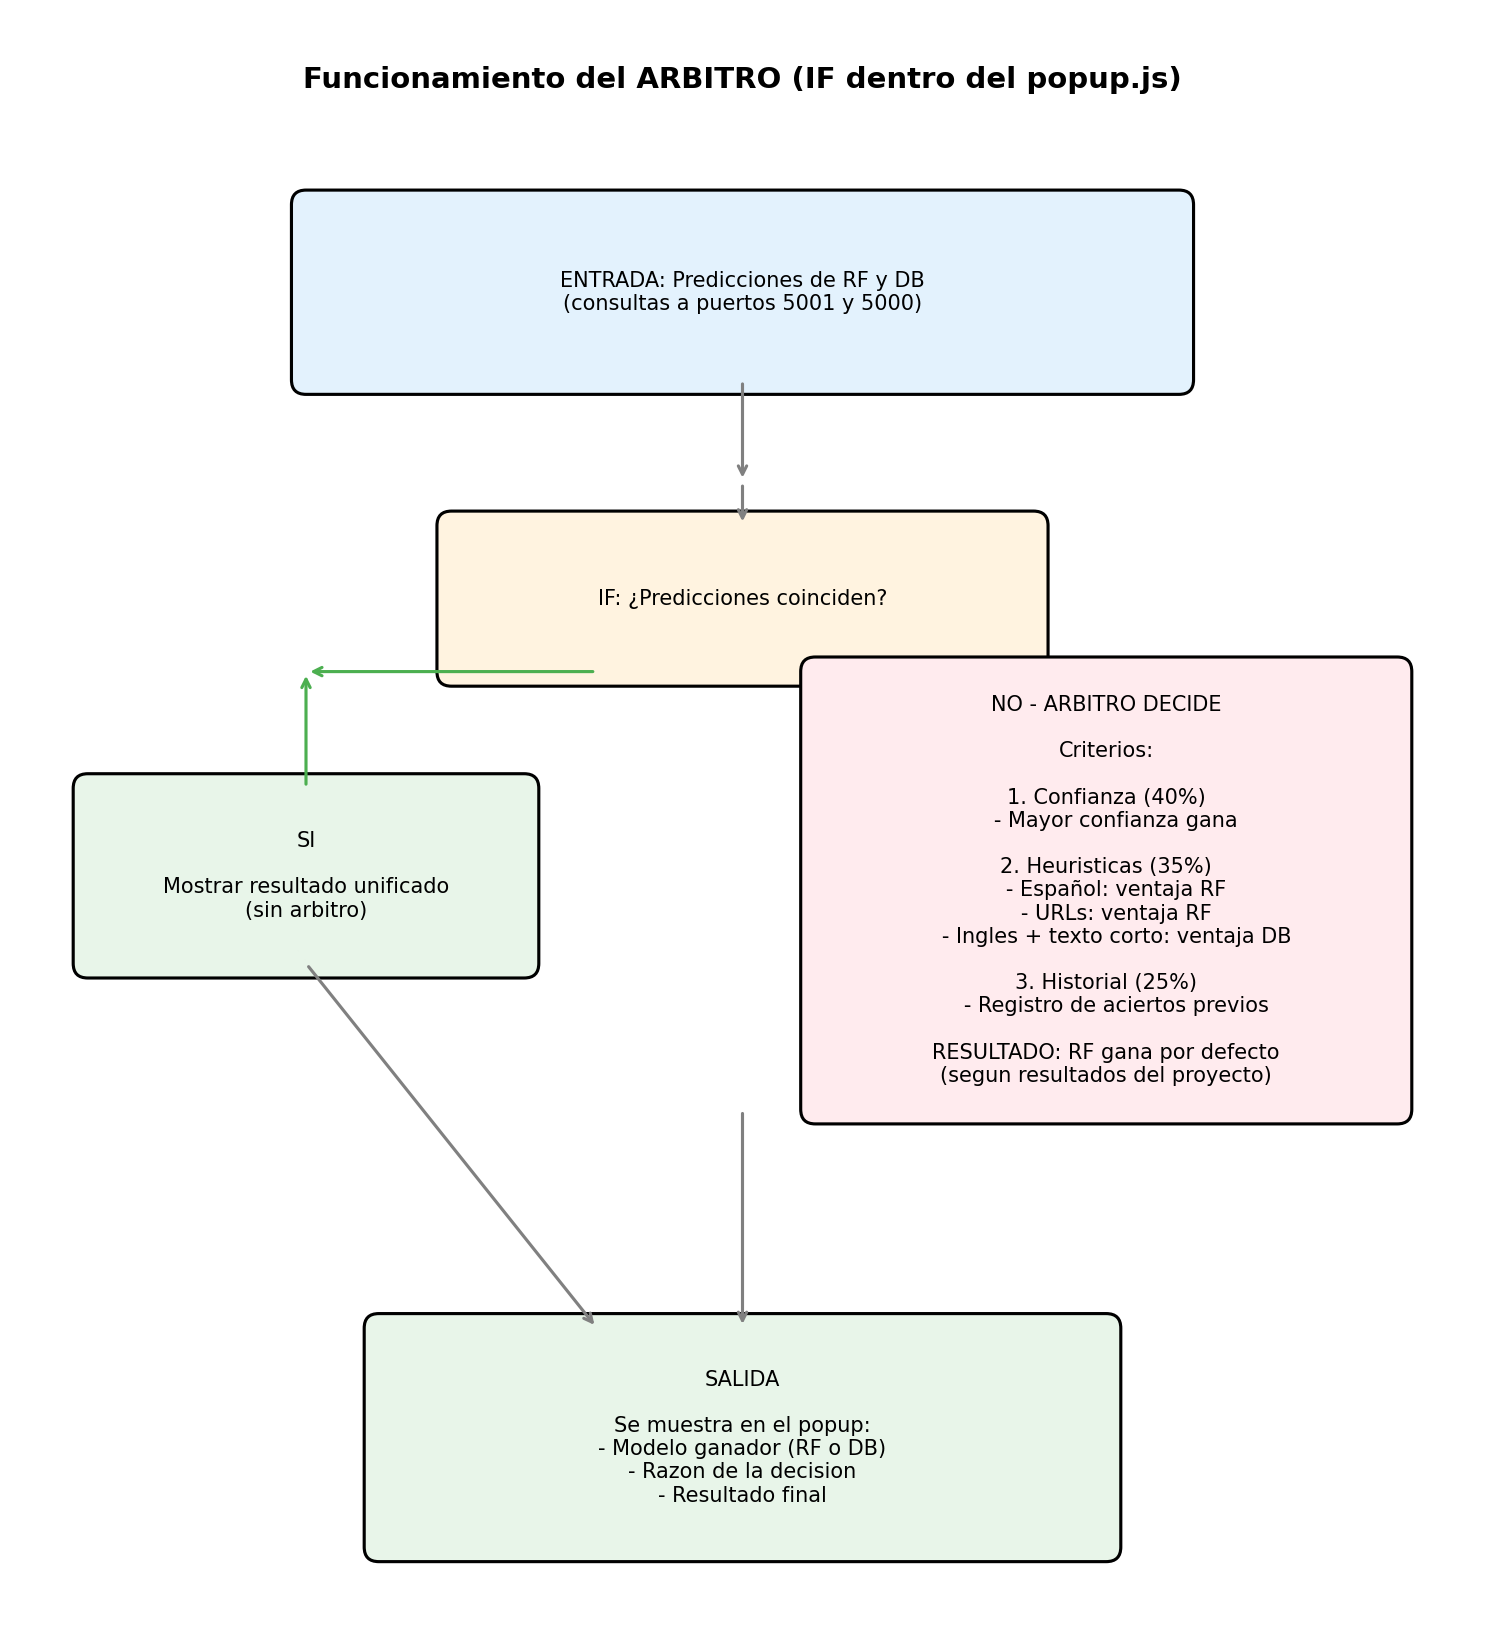

In [7]:
# diagrama_arbitro.py
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(1, 1, figsize=(10, 11))
ax.set_xlim(0, 10)
ax.set_ylim(0, 11)
ax.axis('off')

def caja(x, y, w, h, texto, color):
    rect = patches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.1",
                                   facecolor=color, edgecolor='black', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, texto, ha='center', va='center', fontsize=10)

def flecha(x1, y1, x2, y2, color='gray'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
               arrowprops=dict(arrowstyle='->', color=color, lw=1.5))

# Título
ax.text(5, 10.5, 'Funcionamiento del ARBITRO (IF dentro del popup.js)', 
        ha='center', fontsize=14, fontweight='bold')

# Entrada: predicciones de RF y DB
caja(2, 8.5, 6, 1.2, 'ENTRADA: Predicciones de RF y DB\n(consultas a puertos 5001 y 5000)', '#e3f2fd')
flecha(5, 8.5, 5, 7.8)

# IF: ¿Predicciones coinciden?
caja(3, 6.5, 4, 1, 'IF: ¿Predicciones coinciden?', '#fff3e0')
flecha(5, 7.8, 5, 7.5)

# Rama SI
caja(0.5, 4.5, 3, 1.2, 'SI\n\nMostrar resultado unificado\n(sin arbitro)', '#e8f5e9')
flecha(4, 6.5, 2, 6.5, '#4caf50')
ax.annotate('', xy=(2, 6.5), xytext=(2, 5.7),
           arrowprops=dict(arrowstyle='->', color='#4caf50', lw=1.5))

# Rama NO (ÁRBITRO decide)
caja(5.5, 3.5, 4, 3.0, 
     'NO - ARBITRO DECIDE\n\nCriterios:\n\n1. Confianza (40%)\n   - Mayor confianza gana\n\n2. Heuristicas (35%)\n   - Español: ventaja RF\n   - URLs: ventaja RF\n   - Ingles + texto corto: ventaja DB\n\n3. Historial (25%)\n   - Registro de aciertos previos\n\nRESULTADO: RF gana por defecto\n(segun resultados del proyecto)', '#ffebee')
flecha(7, 6.5, 7, 6.5, '#f44336')  # Flecha roja para la rama NO

# Salida
caja(2.5, 0.5, 5, 1.5, 
     'SALIDA\n\nSe muestra en el popup:\n- Modelo ganador (RF o DB)\n- Razon de la decision\n- Resultado final', '#e8f5e9')
flecha(5, 3.5, 5, 2.0)
flecha(2, 4.5, 4, 2.0)

plt.tight_layout()
plt.savefig('fig_diagrama_arbitro.png', dpi=150, bbox_inches='tight')
plt.show()

✅ Diagrama guardado como 'fig_arquitectura_sistema.png'


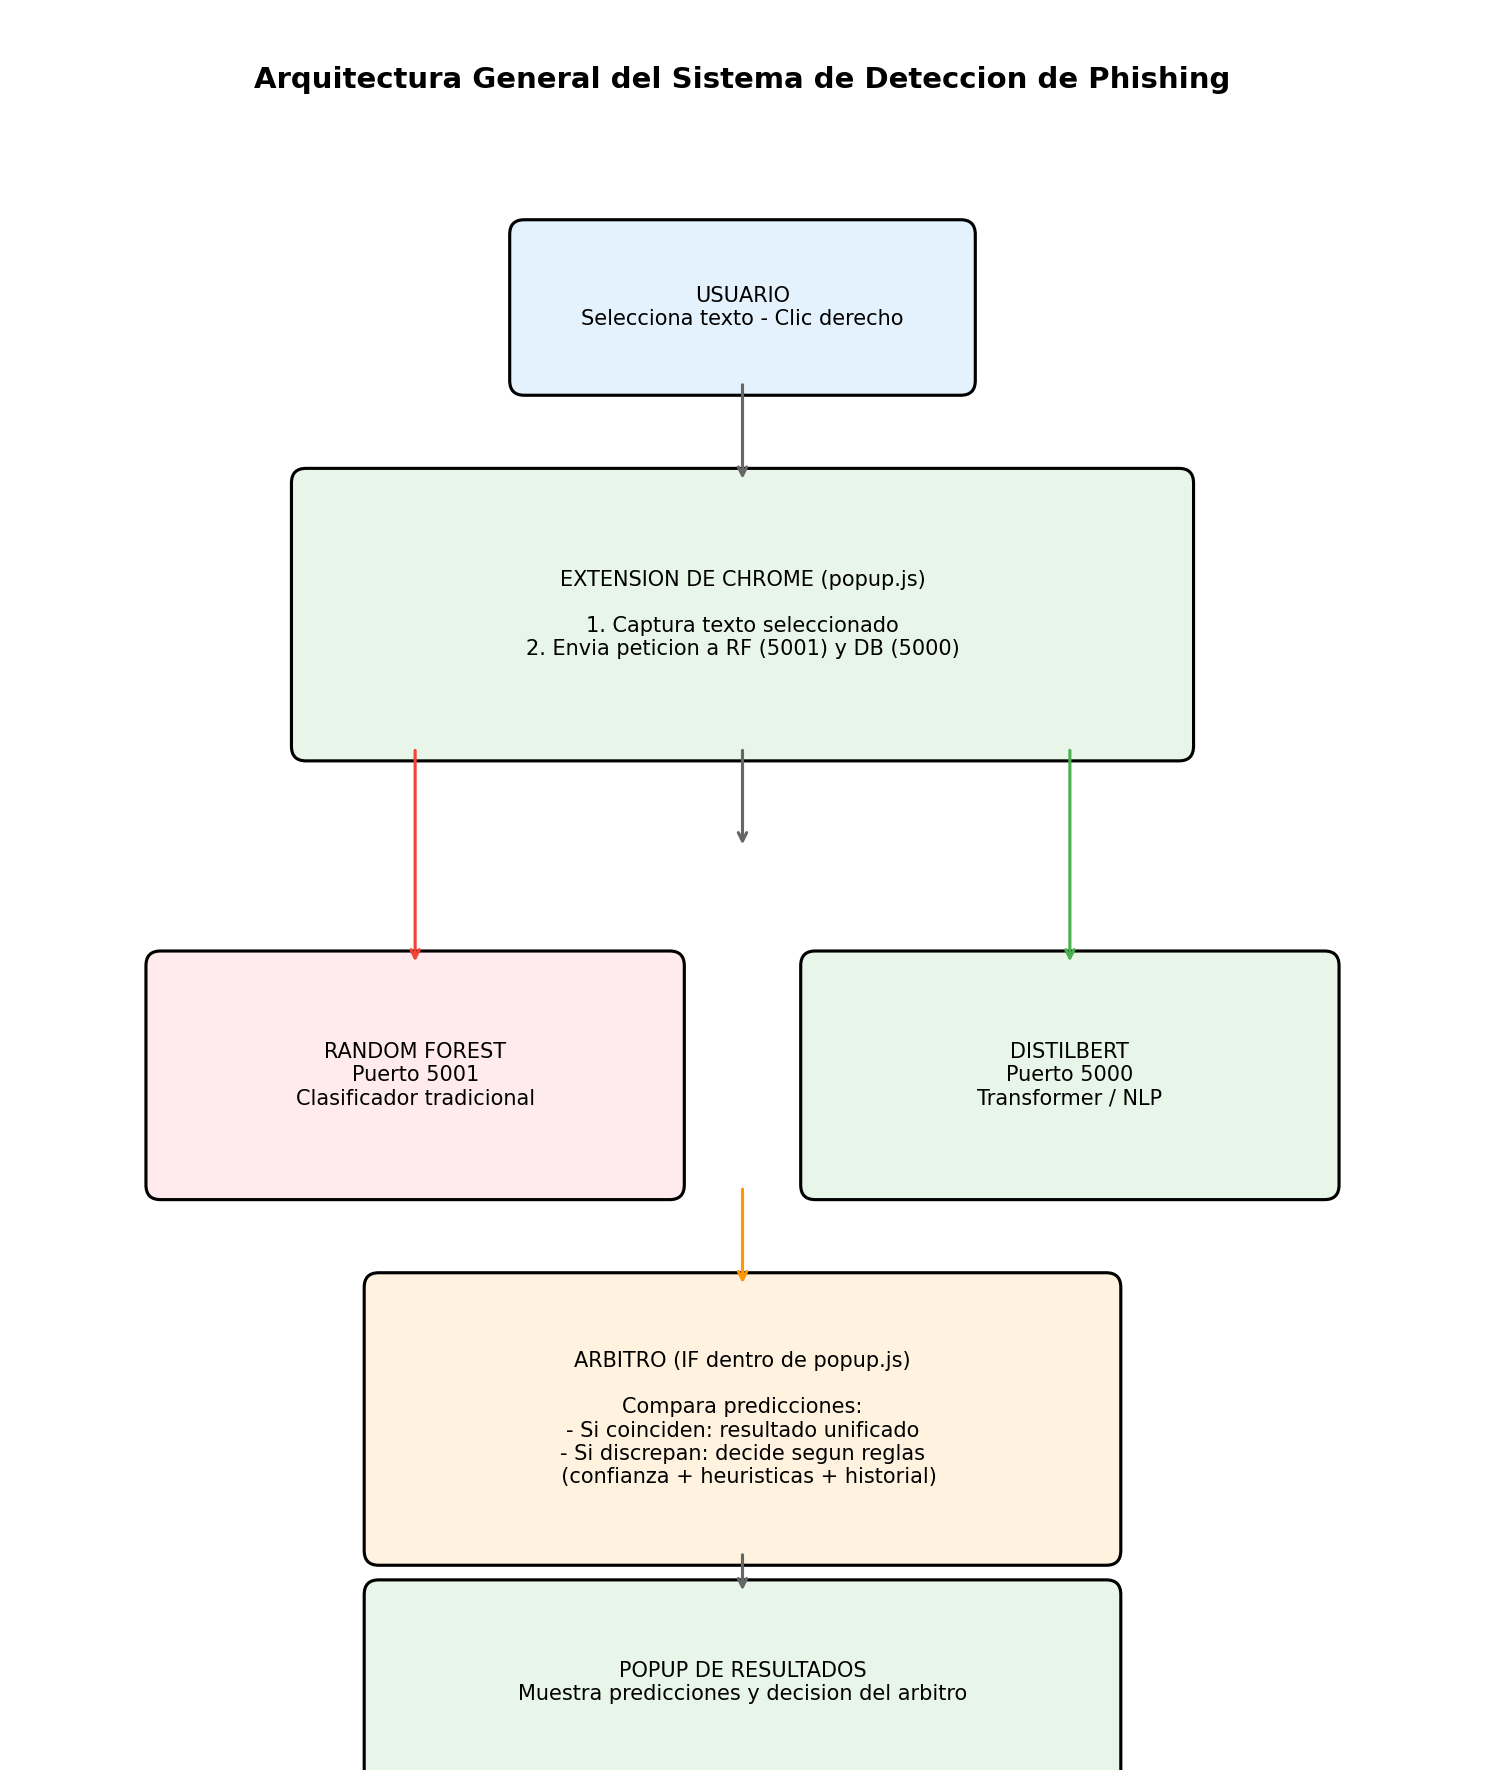

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(1, 1, figsize=(10, 12))
ax.set_xlim(0, 10)
ax.set_ylim(0, 12)
ax.axis('off')

def caja(x, y, w, h, texto, color):
    rect = patches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.1",
                                   facecolor=color, edgecolor='black', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, texto, ha='center', va='center', fontsize=10)

def flecha(x1, y1, x2, y2, color='#666'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
               arrowprops=dict(arrowstyle='->', color=color, lw=1.5))

# Título
ax.text(5, 11.5, 'Arquitectura General del Sistema de Deteccion de Phishing', 
        ha='center', fontsize=14, fontweight='bold')

# Usuario
caja(3.5, 9.5, 3, 1, 'USUARIO\nSelecciona texto - Clic derecho', '#e3f2fd')
flecha(5, 9.5, 5, 8.8)

# Extensión Chrome
caja(2, 7.0, 6, 1.8, 'EXTENSION DE CHROME (popup.js)\n\n1. Captura texto seleccionado\n2. Envia peticion a RF (5001) y DB (5000)', '#e8f5e9')
flecha(5, 7.0, 5, 6.3)

# Random Forest
caja(1, 4.0, 3.5, 1.5, 'RANDOM FOREST\nPuerto 5001\nClasificador tradicional', '#ffebee')
flecha(2.75, 7.0, 2.75, 5.5, '#f44336')

# DistilBERT
caja(5.5, 4.0, 3.5, 1.5, 'DISTILBERT\nPuerto 5000\nTransformer / NLP', '#e8f5e9')
flecha(7.25, 7.0, 7.25, 5.5, '#4caf50')

# ÁRBITRO (IF dentro de popup.js)
caja(2.5, 1.5, 5, 1.8, 'ARBITRO (IF dentro de popup.js)\n\nCompara predicciones:\n- Si coinciden: resultado unificado\n- Si discrepan: decide segun reglas\n  (confianza + heuristicas + historial)', '#fff3e0')
flecha(5, 4.0, 5, 3.3, '#ff9800')

# Popup de resultados
caja(2.5, 0, 5, 1.2, 'POPUP DE RESULTADOS\nMuestra predicciones y decision del arbitro', '#e8f5e9')
flecha(5, 1.5, 5, 1.2)

plt.tight_layout()
plt.savefig('fig_arquitectura_sistema.png', dpi=150, bbox_inches='tight')
print("✅ Diagrama guardado como 'fig_arquitectura_sistema.png'")
plt.show()

✅ Diagrama guardado como 'fig_diagrama_arbitro.png'


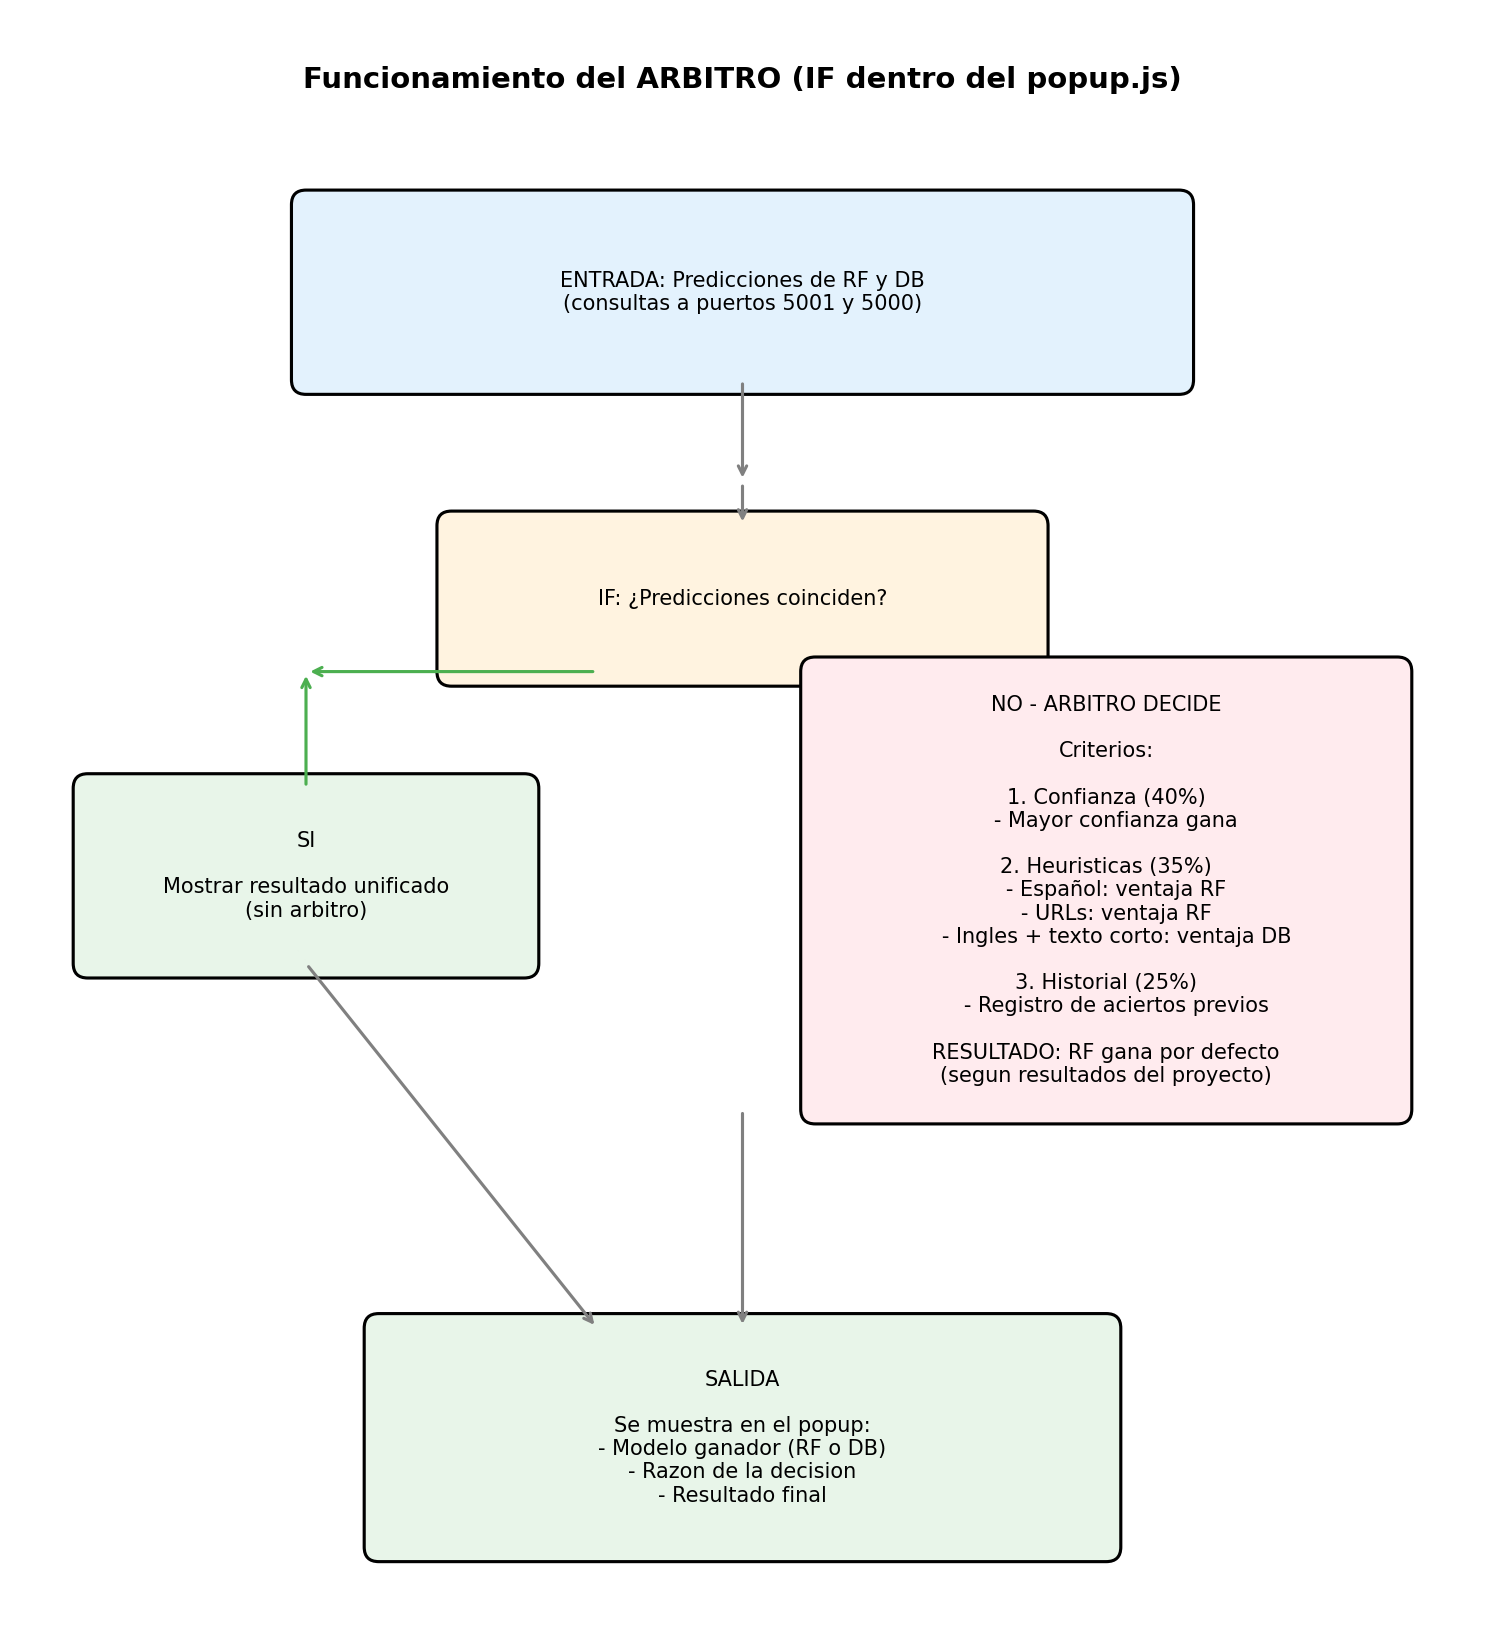

In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(1, 1, figsize=(10, 11))
ax.set_xlim(0, 10)
ax.set_ylim(0, 11)
ax.axis('off')

def caja(x, y, w, h, texto, color):
    rect = patches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.1",
                                   facecolor=color, edgecolor='black', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, texto, ha='center', va='center', fontsize=10)

def flecha(x1, y1, x2, y2, color='gray'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
               arrowprops=dict(arrowstyle='->', color=color, lw=1.5))

# Título
ax.text(5, 10.5, 'Funcionamiento del ARBITRO (IF dentro del popup.js)', 
        ha='center', fontsize=14, fontweight='bold')

# Entrada: predicciones de RF y DB
caja(2, 8.5, 6, 1.2, 'ENTRADA: Predicciones de RF y DB\n(consultas a puertos 5001 y 5000)', '#e3f2fd')
flecha(5, 8.5, 5, 7.8)

# IF: ¿Predicciones coinciden?
caja(3, 6.5, 4, 1, 'IF: ¿Predicciones coinciden?', '#fff3e0')
flecha(5, 7.8, 5, 7.5)

# Rama SI
caja(0.5, 4.5, 3, 1.2, 'SI\n\nMostrar resultado unificado\n(sin arbitro)', '#e8f5e9')
flecha(4, 6.5, 2, 6.5, '#4caf50')
ax.annotate('', xy=(2, 6.5), xytext=(2, 5.7),
           arrowprops=dict(arrowstyle='->', color='#4caf50', lw=1.5))

# Rama NO (ÁRBITRO decide)
caja(5.5, 3.5, 4, 3.0, 
     'NO - ARBITRO DECIDE\n\nCriterios:\n\n1. Confianza (40%)\n   - Mayor confianza gana\n\n2. Heuristicas (35%)\n   - Español: ventaja RF\n   - URLs: ventaja RF\n   - Ingles + texto corto: ventaja DB\n\n3. Historial (25%)\n   - Registro de aciertos previos\n\nRESULTADO: RF gana por defecto\n(segun resultados del proyecto)', '#ffebee')
flecha(7, 6.5, 7, 6.5, '#f44336')

# Salida
caja(2.5, 0.5, 5, 1.5, 
     'SALIDA\n\nSe muestra en el popup:\n- Modelo ganador (RF o DB)\n- Razon de la decision\n- Resultado final', '#e8f5e9')
flecha(5, 3.5, 5, 2.0)
flecha(2, 4.5, 4, 2.0)

plt.tight_layout()
plt.savefig('fig_diagrama_arbitro.png', dpi=150, bbox_inches='tight')
print("✅ Diagrama guardado como 'fig_diagrama_arbitro.png'")
plt.show()